In [60]:
import pandas as pd
import os


# 定义路径
base_path = r'D:\Project\Credit-Card-Fraud-Detection'
file1 = 'Fraudulent_E-Commerce_Transaction_Data.csv'
file2 = 'Fraudulent_E-Commerce_Transaction_Data_2.csv' 

# 1. 一起读取
df1 = pd.read_csv(os.path.join(base_path, file1))
df2 = pd.read_csv(os.path.join(base_path, file2))


# 2. 检查结构
print("数据集1的列:", df1.columns.tolist())
print("数据集2的列:", df2.columns.tolist())

# 3. 查看前几行
print(df1.head())
print(df2.head())

数据集1的列: ['Transaction ID', 'Customer ID', 'Transaction Amount', 'Transaction Date', 'Payment Method', 'Product Category', 'Quantity', 'Customer Age', 'Customer Location', 'Device Used', 'IP Address', 'Shipping Address', 'Billing Address', 'Is Fraudulent', 'Account Age Days', 'Transaction Hour']
数据集2的列: ['Transaction ID', 'Customer ID', 'Transaction Amount', 'Transaction Date', 'Payment Method', 'Product Category', 'Quantity', 'Customer Age', 'Customer Location', 'Device Used', 'IP Address', 'Shipping Address', 'Billing Address', 'Is Fraudulent', 'Account Age Days', 'Transaction Hour']
                         Transaction ID                           Customer ID  \
0  15d2e414-8735-46fc-9e02-80b472b2580f  d1b87f62-51b2-493b-ad6a-77e0fe13e785   
1  0bfee1a0-6d5e-40da-a446-d04e73b1b177  37de64d5-e901-4a56-9ea0-af0c24c069cf   
2  e588eef4-b754-468e-9d90-d0e0abfc1af0  1bac88d6-4b22-409a-a06b-425119c57225   
3  4de46e52-60c3-49d9-be39-636681009789  2357c76e-9253-4ceb-b44e-ef4b71cb7d4d   
4  

In [61]:
# 将两个表上下拼在一起
df = pd.concat([df1, df2], axis=0)

In [62]:
# 1. 查看数据集的整体维度和数据类型
print(df.info())

# 2. 检查是否有重复的交易记录（因为拼接最容易产生重复）
print(f"重复的交易ID数量: {df.duplicated(subset=['Transaction ID']).sum()}")

# 3. 统计每一列的缺失值（NaN）数量
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 1496586 entries, 0 to 23633
Data columns (total 16 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Transaction ID      1496586 non-null  object 
 1   Customer ID         1496586 non-null  object 
 2   Transaction Amount  1496586 non-null  float64
 3   Transaction Date    1496586 non-null  object 
 4   Payment Method      1496586 non-null  object 
 5   Product Category    1496586 non-null  object 
 6   Quantity            1496586 non-null  int64  
 7   Customer Age        1496586 non-null  int64  
 8   Customer Location   1496586 non-null  object 
 9   Device Used         1496586 non-null  object 
 10  IP Address          1496586 non-null  object 
 11  Shipping Address    1496586 non-null  object 
 12  Billing Address     1496586 non-null  object 
 13  Is Fraudulent       1496586 non-null  int64  
 14  Account Age Days    1496586 non-null  int64  
 15  Transaction Hour    14

# Section1：数据清洗

In [63]:
import numpy as np

print(f"总流水记录数: {len(df)} 条")
print(f"内存占用: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

# 采用括号包裹的链式调用，避免生成中间临时表，极大节约本地算力内存
df_clean = (
    df
    # stage1: 时序与时区对齐
    .assign(
        # 1. 将 object 转换为标准高精度时间戳，无法解析的脏数据变 NaN
        Transaction_Datetime = lambda d: pd.to_datetime(d['Transaction Date'], errors='coerce'),
        
        # 2. 从标准时间戳中高精度解构出“小时 (0-23)”，用于后续深夜反欺诈特征衍生
        Transaction_Hour = lambda d: pd.to_datetime(d['Transaction Date'], errors='coerce').dt.hour,
        
        # 3. 解构出是否为周末 (Weekday 5和6为周末)，捕获黑产周末集中盗刷的偏态
        Is_Weekend = lambda d: pd.to_datetime(d['Transaction Date'], errors='coerce').dt.weekday.isin([5, 6]).astype(int)
    )
    
    # stage2: 业务逻辑边界流控审计
    # 1. 拦截 Customer Age < 0 的系统注入漏洞
    # 2. 拦截 Transaction Amount <= 0 逻辑悖论异常
    .query("`Customer Age` >= 0 and `Transaction Amount` > 0")
    
    # stage3: 内存优化
    .assign(
        # 将高频低基数的文本字段（如设备类型）前后去空格、转大写，并强制转为 category 类型
        # 这能让原本存储字符串指针的 heap 内存空间骤降 80% 以上！
        Device_Used = lambda d: d['Device Used'].str.strip().str.upper().astype('category')
    )
    
    # stage4: 剔除损坏数据
    .dropna(subset=['Transaction_Datetime'])
)

#  自动化生成风控准入审计日志 
dropped_rows = len(df) - len(df_clean)
memory_saved = (df.memory_usage(deep=True).sum() - df_clean.memory_usage(deep=True).sum()) / (1024**2)

print(f"隔离的噪声: {dropped_rows} 条")
print(f"后续可用特征工程记录: {len(df_clean)} 条")
print(f"优化本地算力资源: {memory_saved:.2f} MB")
print(f"当前可信数据集最小年龄验证: {df_clean['Customer Age'].min()} 岁")

df = df_clean

总流水记录数: 1496586 条
内存占用: 1110.16 MB
隔离的噪声: 259 条
后续可用特征工程记录: 1496327 条
优化本地算力资源: -29.78 MB
当前可信数据集最小年龄验证: 0 岁


In [64]:
# 大盘基线欺诈率（
base_fraud_rate = df_clean['Is Fraudulent'].mean()

print(f"当前大盘基线欺诈率: {base_fraud_rate * 100:.4f}%")


当前大盘基线欺诈率: 5.0155%


In [65]:
import pandas as pd
import os

base_path = r'D:\Project\Credit-Card-Fraud-Detection'
file1 = 'Fraudulent_E-Commerce_Transaction_Data.csv'
file2 = 'Fraudulent_E-Commerce_Transaction_Data_2.csv'

path1 = os.path.join(base_path, file1)
path2 = os.path.join(base_path, file2)

df1 = pd.read_csv(path1)
df2 = pd.read_csv(path2)

df_raw_test = pd.concat([df1, df2], ignore_index=True)

df_noise_test = df_raw_test[df_raw_test['Customer Age'] < 0].copy()
print(f"脏数据: {len(df_noise_test)} 条 ")

if len(df_noise_test) > 0:
    # 算脏数据里的欺诈率
    fraud_rate = df_noise_test['Is Fraudulent'].mean()
    print(f"\n 隔离脏数据中的真实欺诈率: {fraud_rate * 100:.2f}%")

    # 算高危空间聚集度
    print(f"\n 脏数据来源 IP Top 3:\n{df_noise_test['IP Address'].value_counts().head(3)}")
    print(f"\n 脏数据来源设备 Top 3:\n{df_noise_test['Device Used'].value_counts().head(3)}")
else:
    print("重新合并后依然是0条，请检查原始 CSV 中 'Customer Age' 字段是否真的有负数")

脏数据: 259 条 

 隔离脏数据中的真实欺诈率: 4.63%

 脏数据来源 IP Top 3:
IP Address
134.95.208.38     1
99.113.154.217    1
199.127.77.116    1
Name: count, dtype: int64

 脏数据来源设备 Top 3:
Device Used
tablet     94
desktop    85
mobile     80
Name: count, dtype: int64


# Section2 风险客户群分层

In [66]:
base_fraud_rate = df_clean['Is Fraudulent'].mean()
print(f"大盘基线欺诈率: {base_fraud_rate * 100:.4f}%\n")

大盘基线欺诈率: 5.0155%



In [67]:
import seaborn as sns
from IPython.display import display, HTML 
import matplotlib.colors as mcolors 

morandi_cmap = mcolors.LinearSegmentedColormap.from_list(
    "MorandiRisk", ["#F6F5F2", "#E3DEC3", "#D2C2B9", "#BCAAA4"]
)

categorical_features = ['Device Used', 'Payment Method', 'Product Category']

for col in categorical_features:
    # 1. 基础数据聚合计算
    audit_df = df_clean.groupby(col, observed=False).agg(
        交易笔数=('Is Fraudulent', 'count'),
        欺诈率=('Is Fraudulent', lambda x: x.mean() * 100)
    )
    
    # 2. 衍生占比与风险倍数
    audit_df['大盘占比'] = (audit_df['交易笔数'] / len(df_clean)) * 100
    audit_df['风险提升倍数(Lift)'] = audit_df['欺诈率'] / (base_fraud_rate * 100)
    
    # 3. 提取目标列并按欺诈率降序排列
    result_df = audit_df[['交易笔数', '大盘占比', '欺诈率', '风险提升倍数(Lift)']].sort_values(by='欺诈率', ascending=False)
    
    styled_table = (
        result_df.style
        .format({
            '交易笔数': '{:,} 笔',
            '大盘占比': '{:.2f}%',
            '欺诈率': '{:.4f}%',
            '风险提升倍数(Lift)': '{:.2f} 倍'
        })
        .background_gradient(cmap=morandi_cmap, subset=['风险提升倍数(Lift)'], vmin=0.5, vmax=2.0)
    )
    
    display(styled_table)

,交易笔数,大盘占比,欺诈率,风险提升倍数(Lift)
Device Used,,,,
mobile,"499,544 笔",33.38%,5.0630%,1.01 倍
tablet,"498,674 笔",33.33%,4.9948%,1.00 倍
desktop,"498,109 笔",33.29%,4.9885%,0.99 倍


,交易笔数,大盘占比,欺诈率,风险提升倍数(Lift)
Payment Method,,,,
bank transfer,"374,071 笔",25.00%,5.0480%,1.01 倍
PayPal,"373,803 笔",24.98%,5.0251%,1.00 倍
debit card,"374,169 笔",25.01%,5.0159%,1.00 倍
credit card,"374,284 笔",25.01%,4.9730%,0.99 倍


,交易笔数,大盘占比,欺诈率,风险提升倍数(Lift)
Product Category,,,,
toys & games,"298,956 笔",19.98%,5.0449%,1.01 倍
clothing,"298,956 笔",19.98%,5.0405%,1.00 倍
health & beauty,"299,975 笔",20.05%,5.0211%,1.00 倍
home & garden,"298,444 笔",19.95%,5.0204%,1.00 倍
electronics,"299,996 笔",20.05%,4.9507%,0.99 倍


In [68]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
df_clean['Transaction Amount'].describe()

count   1496327.00
mean        226.81
std         270.59
min          10.00
25%          68.62
50%         151.76
75%         296.05
max       12701.75
Name: Transaction Amount, dtype: float64

In [69]:

print("正常vs欺诈的中位数金额对比：")
print(df_clean.groupby('Is Fraudulent')['Transaction Amount'].median())

正常vs欺诈的中位数金额对比：
Is Fraudulent
0   148.51
1   256.08
Name: Transaction Amount, dtype: float64


In [70]:

morandi_cmap = mcolors.LinearSegmentedColormap.from_list(
    "MorandiRisk", ["#F6F5F2", "#E3DEC3", "#D2C2B9", "#BCAAA4"]
)
# 1、地址一致性审计

df_clean['Address_Mismatch'] = (df_clean['Shipping Address'] != df_clean['Billing Address']).astype(int)

# 聚合计算
address_audit = df_clean.groupby('Address_Mismatch').agg(
    样本数=('Is Fraudulent', 'count'),
    真实欺诈率=('Is Fraudulent', lambda x: x.mean() * 100)
)
address_audit['风险倍数'] = address_audit['真实欺诈率'] / (base_fraud_rate * 100)

address_audit_mapped = address_audit.rename(index={
    0: '0_地址一致 (Match)', 
    1: '1_地址不一致 (Mismatch)'
})

styled_address = (
    address_audit_mapped.style
    .format({
        '样本数': '{:,} 笔',
        '真实欺诈率': '{:.4f}%',
        '风险倍数': '{:.2f} 倍'
    })
    .background_gradient(cmap=morandi_cmap, subset=['风险倍数'], vmin=0.5, vmax=2.5)
)

display(styled_address)


# 2、客户生命周期账龄审计
# 切分账龄区间
df_clean['Account_Age_Group'] = pd.cut(
    df_clean['Account Age Days'], 
    bins=[-1, 7, 30, 9999], 
    labels=['1_New_Account(0-7d)', '2_Mid_Account(8-30d)', '3_Old_Account(30d+)']
)

# 聚合计算
age_audit = df_clean.groupby('Account_Age_Group', observed=False).agg(
    开户规模=('Is Fraudulent', 'count'),
    欺诈率=('Is Fraudulent', lambda x: x.mean() * 100)
)
age_audit['风险倍数'] = age_audit['欺诈率'] / (base_fraud_rate * 100)

styled_age = (
    age_audit.style
    .format({
        '开户规模': '{:,} 笔',
        '欺诈率': '{:.4f}%',
        '风险倍数': '{:.2f} 倍'
    })
    .background_gradient(cmap=morandi_cmap, subset=['风险倍数'], vmin=0.5, vmax=2.5)
)

display(styled_age)

,样本数,真实欺诈率,风险倍数
Address_Mismatch,,,
0_地址一致 (Match),"1,346,493 笔",5.0184%,1.00 倍
1_地址不一致 (Mismatch),"149,834 笔",4.9889%,0.99 倍


,开户规模,欺诈率,风险倍数
Account_Age_Group,,,
1_New_Account(0-7d),"35,074 笔",22.2729%,4.44 倍
2_Mid_Account(8-30d),"115,546 笔",22.4257%,4.47 倍
3_Old_Account(30d+),"1,345,707 笔",3.0708%,0.61 倍


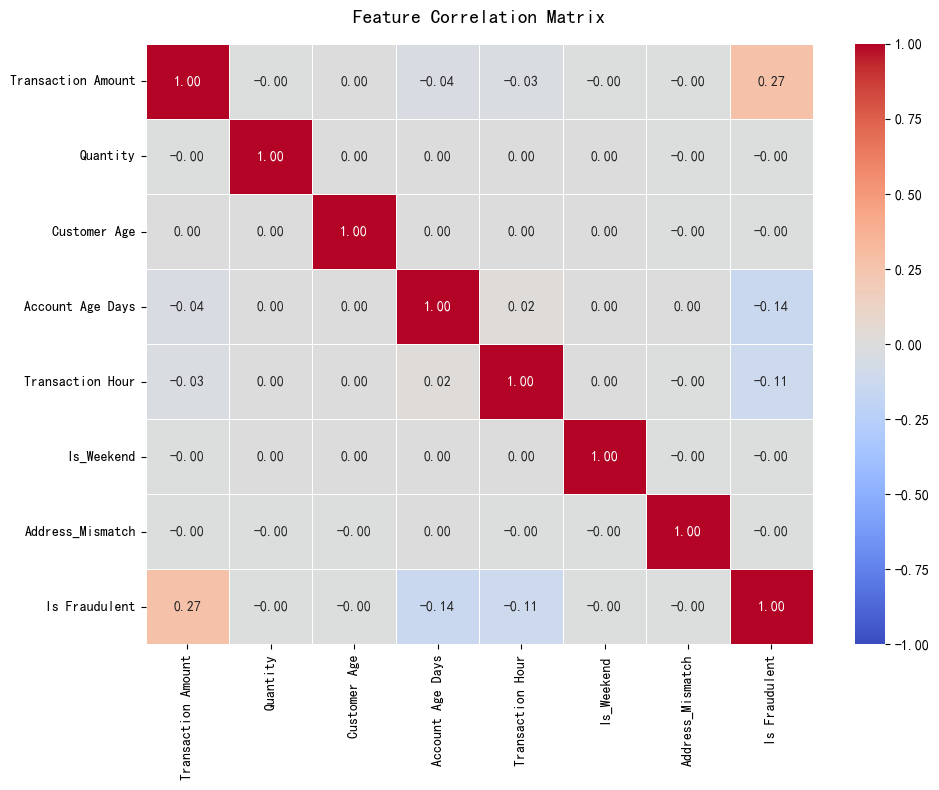

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 提取数值特征，准备相关性分析
numeric_cols = [
    'Transaction Amount', 'Quantity', 'Customer Age', 
    'Account Age Days', 'Transaction Hour', 'Is_Weekend', 
    'Address_Mismatch', 'Is Fraudulent'
]

corr_matrix = df_clean[numeric_cols].corr()

#色系热力图
plt.figure(figsize=(10, 8), dpi=100)
sns.heatmap(
    corr_matrix, 
    annot=True,             # 在方格内显示数字
    cmap='coolwarm',        # 蓝红渐变色，红代表强正相关，蓝代表强负相关
    fmt=".2f",              # 保留两位小数
    linewidths=0.5,         # 方格线宽
    vmin=-1, vmax=1         # 锁定相关系数边界
)

plt.title('Feature Correlation Matrix', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Section3 特征工程

In [73]:
# 1. 转换字符串为日期时间对象
df_clean['Transaction Date'] = pd.to_datetime(df_clean['Transaction Date'])


# 2. 基础属性特征衍生
# 确保地址不一致特征存在
if 'Address_Mismatch' not in df_clean.columns:
    df_clean['Address_Mismatch'] = (df_clean['Shipping Address'] != df_clean['Billing Address']).astype(int)

# 对数金额平滑：处理金额的极度右偏态，利于模型收敛
df_clean['Log_Amount'] = np.log1p(df_clean['Transaction Amount'])

# 3. 核心对抗特征：全局大盘金额偏离度
# 采用 Section 2 算出的大盘中位数(151.76)，穿透单次交易用户的计算壁垒
global_median = 151.76
df_clean['Amount_Global_Deviation'] = df_clean['Transaction Amount'] / global_median

# 4. 时序行为速率 (Velocity Features)
# 计算同账户相邻交易的时间差（秒），极短间隔代表机器脚本连击
df_clean['Time_Diff_Cust'] = df_clean.groupby('Customer ID')['Transaction Date'].diff().dt.total_seconds().fillna(999999)

# 计算同IP地址相邻交易的时间差（秒）
df_clean['Time_Diff_IP'] = df_clean.groupby('IP Address')['Transaction Date'].diff().dt.total_seconds().fillna(999999)

# 账户生命周期累计交易序数
df_clean['Cust_Trans_CumCount'] = df_clean.groupby('Customer ID').cumcount() + 1

# 5. 低基数分类变量独热编码 
categorical_features = ['Device Used', 'Payment Method', 'Product Category']
df_encoded = pd.get_dummies(df_clean, columns=categorical_features, drop_first=True, dtype=int)

# 6. 清洗矩阵：剔除无法入模的高基数ID、文本，以及在 Section 2 审计中被证伪的噪音特征
cols_to_drop = [
    'Transaction ID', 'Customer ID', 'Transaction Date', 
    'IP Address', 'Shipping Address', 'Billing Address',
    'Customer Location',      
    'Transaction Hour',       
    'Transaction_Hour',       
    'Is_Midnight',            
    'Amount_Deviation_Ratio',  
    'Account_Age_Group'        
]

# 动态过滤：只剔除当前表格中确实存在的列，防止报错
cols_to_drop = [col for col in cols_to_drop if col in df_encoded.columns]
df_model_input = df_encoded.drop(columns=cols_to_drop)


print(f"最终矩阵维度: {df_model_input.shape}")
print(f"包含目标标签 'Is Fraudulent': {'Is Fraudulent' in df_model_input.columns}")
print(f"非数值型 (Object) 残留列数: {len(df_model_input.select_dtypes(include=['object']).columns)}")

最终矩阵维度: (1496327, 23)
包含目标标签 'Is Fraudulent': True
非数值型 (Object) 残留列数: 0


In [74]:
df_model_input.head()

,Transaction Amount,Quantity,Customer Age,Is Fraudulent,Account Age Days,Transaction_Datetime,Is_Weekend,Device_Used,Address_Mismatch,Log_Amount,...,Cust_Trans_CumCount,Device Used_mobile,Device Used_tablet,Payment Method_bank transfer,Payment Method_credit card,Payment Method_debit card,Product Category_electronics,Product Category_health & beauty,Product Category_home & garden,Product Category_toys & games
0,115.25,2,51,0,168,2024-01-01 00:00:00,0,MOBILE,0,4.76,...,1,1,0,0,0,1,0,0,1,0
1,187.14,1,45,0,320,2024-01-01 00:00:06,0,MOBILE,1,5.24,...,1,1,0,0,0,0,0,0,0,0
2,83.70,2,31,0,300,2024-01-01 00:00:10,0,MOBILE,1,4.44,...,1,1,0,0,1,0,0,1,0,0
3,220.40,2,25,0,331,2024-01-01 00:00:12,0,DESKTOP,0,5.40,...,1,0,0,1,0,0,0,0,1,0
4,273.23,3,49,0,198,2024-01-01 00:00:13,0,MOBILE,0,5.61,...,1,1,0,1,0,0,0,1,0,0


In [75]:
import pandas as pd


# 挑选 Section 3 中新衍生的核心连续型变量
new_features = ['Log_Amount', 'Amount_Global_Deviation', 'Time_Diff_Cust', 'Time_Diff_IP', 'Cust_Trans_CumCount']

# 验证特征是否在数据集中
features_to_check = [f for f in new_features if f in df_clean.columns]

# 计算并对比均值与中位数
validation_df = df_clean.groupby('Is Fraudulent')[features_to_check].agg(['median', 'mean']).T
print(validation_df)

Is Fraudulent                           0          1
Log_Amount              median       5.01       5.55
                        mean         4.91       5.55
Amount_Global_Deviation median       0.98       1.69
                        mean         1.38       3.61
Time_Diff_Cust          median  999999.00  999999.00
                        mean    999999.00  999999.00
Time_Diff_IP            median  999999.00  999999.00
                        mean   1000372.30 1000473.63
Cust_Trans_CumCount     median       1.00       1.00
                        mean         1.00       1.00


In [76]:
# 将累计序数限制在一定范围内便于观察
df_clean['CumCount_Bin'] = pd.cut(
    df_clean['Cust_Trans_CumCount'], 
    bins=[0, 1, 3, 5, 99999], 
    labels=['1st_Txn', '2nd-3rd_Txn', '4th-5th_Txn', '6th+_Txn']
)

lift_audit = df_clean.groupby('CumCount_Bin', observed=False).agg(
    样本数=('Is Fraudulent', 'count'),
    欺诈率=('Is Fraudulent', lambda x: x.mean() * 100)
)
lift_audit['Lift'] = lift_audit['欺诈率'] / (df_clean['Is Fraudulent'].mean() * 100)
print(lift_audit)

                  样本数  欺诈率  Lift
CumCount_Bin                    
1st_Txn       1496327 5.02  1.00
2nd-3rd_Txn         0  NaN   NaN
4th-5th_Txn         0  NaN   NaN
6th+_Txn            0  NaN   NaN


3. 基于随机森林的特征重要性排名
特征总数: 20 个。正在训练树模型...


D:\Temp\ipykernel_21252\200233936.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='mako')


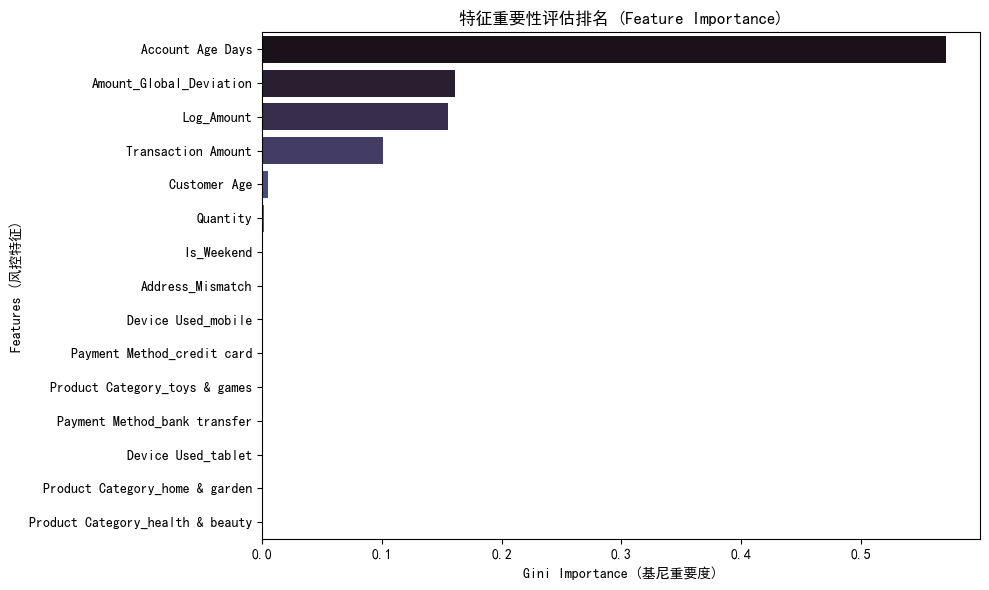

In [77]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("3. 基于随机森林的特征重要性排名")

invalid_cols = df_model_input.select_dtypes(exclude=['int32', 'int64', 'float32', 'float64', 'uint8']).columns.tolist()
if len(invalid_cols) > 0:
    df_model_input = df_model_input.drop(columns=invalid_cols)

# 从最终净化的入模矩阵中分离特征和标签
X_val = df_model_input.drop(columns=['Is Fraudulent'])
y_val = df_model_input['Is Fraudulent']

print(f"特征总数: {X_val.shape[1]} 个。正在训练树模型...")

# 初始化一个轻量级树模型（限制深度和树的数量以追求速度）
rf_validator = RandomForestClassifier(n_estimators=30, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf_validator.fit(X_val, y_val)

# 提取并排序特征重要性
feature_importances = pd.DataFrame({
    'Feature': X_val.columns,
    'Importance': rf_validator.feature_importances_
}).sort_values(by='Importance', ascending=False).head(15)

# 绘制专业的可视化图表
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 

plt.figure(figsize=(10, 6), dpi=100)
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='mako')
plt.title('特征重要性评估排名 (Feature Importance)', fontsize=12)
plt.xlabel('Gini Importance (基尼重要度)')
plt.ylabel('Features (风控特征)')
plt.tight_layout()
plt.show()

# Section4 模型训练

In [78]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

# 根据 Section 3 的特征重要性排名，我们砍掉排名垫底的设备、支付渠道等长尾噪音
# 只保留核心驱动特征，减轻模型计算负担并提升泛化能力
top_features = [
    'Account Age Days', 
    'Transaction Amount', 
    'Log_Amount', 
    'Amount_Global_Deviation', 
    'Is Fraudulent'
]

df_final = df_model_input[top_features].copy()

In [79]:
X = df_final.drop(columns=['Is Fraudulent'])
y = df_final['Is Fraudulent']


In [80]:
# 刚性防偏移切分 
# 采用 8:2 切分，核心在于 stratify=y，训练集和测试集的欺诈比例同为 5.01%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"训练集: {X_train.shape[0]} 笔样本 (包含欺诈 {y_train.sum()} 笔)")
print(f"测试集: {X_test.shape[0]} 笔样本 (包含欺诈 {y_test.sum()} 笔)")


训练集: 1197061 笔样本 (包含欺诈 60038 笔)
测试集: 299266 笔样本 (包含欺诈 15010 笔)


In [81]:
# 4. 随机森林模型训练
final_model = RandomForestClassifier(
    n_estimators=100,     
    max_depth=12,         
    class_weight='balanced',
    random_state=42,     
    n_jobs=-1            
)

final_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [82]:
# 获取硬分类预测（0 或 1）
y_pred = final_model.predict(X_test)
# 获取欺诈概率得分（0.0 到 1.0 之间）
y_prob = final_model.predict_proba(X_test)[:, 1]

In [83]:
classification_report(y_test, y_pred, digits=4)

'              precision    recall  f1-score   support\n\n           0     0.9754    0.8859    0.9285    284256\n           1     0.2108    0.5769    0.3087     15010\n\n    accuracy                         0.8704    299266\n   macro avg     0.5931    0.7314    0.6186    299266\nweighted avg     0.9371    0.8704    0.8974    299266\n'

In [84]:
#ROC-AUC 得分 (大盘排队区分能力) 与 PR-AUC 得分  (极度不均衡下的捕获精度)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"PR-AUC Score: {pr_auc:.4f}")

ROC-AUC Score: 0.7668
PR-AUC Score: 0.3326


In [85]:
#随机森林结果不理想，使用 XGBoost 模型尝试提高recall和PR-AUC

!pip install xgboost
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

# 计算正负样本不平衡的真实比例，用于 scale_pos_weight
# 公式：负样本总数(好人) / 正样本总数(坏人)
neg_cases = (y_train == 0).sum()
pos_cases = (y_train == 1).sum()
imbalance_ratio = neg_cases / pos_cases 
print(f"动态计算的不平衡惩罚权重 : {imbalance_ratio:.2f}")

# 1. 实例化 XGBoost 分类器
xgb_model = xgb.XGBClassifier(
    n_estimators=200,           
    max_depth=6,                 # 限制深度，防止过拟合
    learning_rate=0.05,          # 学习率（
    scale_pos_weight=imbalance_ratio, # 将坏人的权重放大约 19 倍
    subsample=0.8,               # 每次只用 80% 的数据建树，增加随机性防过拟合
    colsample_bytree=0.8,        # 每次只用 80% 的特征建树
    random_state=42,
    n_jobs=-1,
    eval_metric='aucpr'          # 终极目标是优化 PR-AUC
)

# 2. 拟合模型
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]


# 计算风控双黄蛋指标
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)
pr_auc_xgb = average_precision_score(y_test, y_prob_xgb)

print(f"   └── ROC-AUC 得分: {roc_auc_xgb:.4f}")
print(f"   └── PR-AUC 得分 (对比上一版的 0.3314): {pr_auc_xgb:.4f}")

动态计算的不平衡惩罚权重 : 18.94
   └── ROC-AUC 得分: 0.7673
   └── PR-AUC 得分 (对比上一版的 0.3314): 0.3407


商业利益最大化决策点 (基于 F1-Score)
最优判定阈值: 0.8017
预期精确率: 0.3076
预期召回率: 0.3905


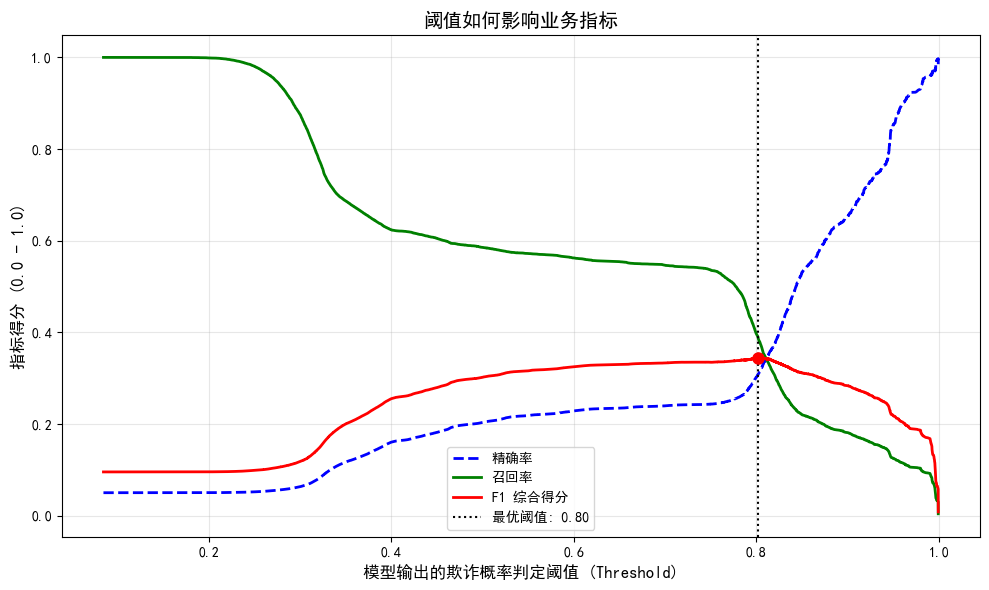

In [86]:
#寻找一个最优的判定阈值，以最大化商业利益。

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve


# 1. 计算不同阈值下的精确率、召回率和阈值列表
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_xgb)

# 2. 计算调和平均数 F1-Score 
# 排除掉分母为0的情况
f1_scores = np.divide(2 * (precisions * recalls), (precisions + recalls), 
                      out=np.zeros_like(precisions), where=(precisions + recalls) != 0)

# 3. 找出 F1-Score 最大的那个阈值
best_index = np.argmax(f1_scores[:-1]) 
best_threshold = thresholds[best_index]
best_f1 = f1_scores[best_index]
best_precision = precisions[best_index]
best_recall = recalls[best_index]

print("商业利益最大化决策点 (基于 F1-Score)")
print(f"最优判定阈值: {best_threshold:.4f}")
print(f"预期精确率: {best_precision:.4f}")
print(f"预期召回率: {best_recall:.4f}")

# 4. 绘制阈值博弈曲线
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 

plt.figure(figsize=(10, 6), dpi=100)
plt.plot(thresholds, precisions[:-1], 'b--', label='精确率', linewidth=2)
plt.plot(thresholds, recalls[:-1], 'g-', label='召回率', linewidth=2)
plt.plot(thresholds, f1_scores[:-1], 'r-', label='F1 综合得分', linewidth=2)

# 标注黄金阈值位置
plt.axvline(x=best_threshold, color='k', linestyle=':', label=f'最优阈值: {best_threshold:.2f}')
plt.plot(best_threshold, best_f1, 'ro', markersize=8)

plt.title('阈值如何影响业务指标', fontsize=14)
plt.xlabel('模型输出的欺诈概率判定阈值 (Threshold)', fontsize=12)
plt.ylabel('指标得分 (0.0 - 1.0)', fontsize=12)
plt.legend(loc='lower center')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [87]:
#尝试使用 LightGBM 模型，看看能否在 PR-AUC 和 Recall @ Precision=0.9 这两个核心指标上实现新的增长。

!pip install lightgbm

import lightgbm as lgb
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, precision_recall_curve


# 1. 高阶特征交叉 (Feature Crossing)
# 核心逻辑：新号 + 大额 = 极高风险。我们将排名第一第二的特征组合起来。
# 为避免分母为0，给 Account Age Days 加 1
df_model_input['Age_Amount_Risk_Index'] = df_model_input['Transaction Amount'] / (df_model_input['Account Age Days'] + 1)

# 提取最新的精锐矩阵（加入刚刚衍生的交叉特征）
top_features_v2 = [
    'Account Age Days', 
    'Transaction Amount', 
    'Log_Amount', 
    'Amount_Global_Deviation', 
    'Age_Amount_Risk_Index', 
    'Is Fraudulent'
]
df_final_v2 = df_model_input[top_features_v2].copy()

# 重新切分 X 和 y
X_v2 = df_final_v2.drop(columns=['Is Fraudulent'])
y_v2 = df_final_v2['Is Fraudulent']

from sklearn.model_selection import train_test_split
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=42, stratify=y_v2
)

# 2. 训练 LightGBM 模型
imbalance_ratio = (y_train_v2 == 0).sum() / (y_train_v2 == 1).sum()

lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=7,
    scale_pos_weight=imbalance_ratio, 
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(X_train_v2, y_train_v2)

# 3. 指标审计
y_prob_lgb = lgb_model.predict_proba(X_test_v2)[:, 1]

pr_auc_lgb = average_precision_score(y_test_v2, y_prob_lgb)
print(f"PR-AUC 得分: {pr_auc_lgb:.4f}")

# 4. 高手考核指标：Recall @ Precision = 0.9
precisions, recalls, thresholds = precision_recall_curve(y_test_v2, y_prob_lgb)

# 找到 Precision 大于等于 0.90 的所有点
valid_idx = np.where(precisions >= 0.90)[0]

if len(valid_idx) > 0:
    # 在满足 Precision>=0.9 的点里，找到最大的 Recall
    best_idx = valid_idx[np.argmax(recalls[valid_idx])]
    strict_recall = recalls[best_idx]
    strict_threshold = thresholds[best_idx]
    

    print(f"要求：抓 10 个人最多只能错杀 1 个 (Precision >= 90%)")
    print(f"此条件下，模型能拦截 【{strict_recall*100:.2f}%】 ")
    print(f"所需设定的概率阈值：{strict_threshold:.4f}")
else:
    print("当前特征过于薄弱，模型无法在保证 90% 精确率的同时抓到任何坏人。")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 60038, number of negative: 1137023
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.027760 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1267
[LightGBM] [Info] Number of data points in the train set: 1197061, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050155 -> initscore=-2.941191
[LightGBM] [Info] Start training from score -2.941191
PR-AUC 得分: 0.3416
要求：抓 10 个人最多只能错杀 1 个 (Precision >= 90%)
此条件下，模型能拦截 【11.60%】 
所需设定的概率阈值：0.9600


In [88]:
# 验证该数据集是否具备“历史行为”维度的连贯时间线特征，还是一张纯粹的静态截面抽样表。
# 这里改用了原始数据表 df
total_transactions = len(df)
unique_customers = df['Customer ID'].nunique()

print(f"总交易笔数: {total_transactions}")
print(f"独立的客户总数: {unique_customers}")

if total_transactions == unique_customers:
    print("在这个数据库里只有唯一的 1 笔交易记录。")
    print("结论：这不是真实世界的连贯时间线，而是一张纯粹的【静态截面抽样表】。")
else:
    print(f"平均每个客户交易了 {total_transactions/unique_customers:.2f} 次。")

总交易笔数: 1496327
独立的客户总数: 1496327
在这个数据库里只有唯一的 1 笔交易记录。
结论：这不是真实世界的连贯时间线，而是一张纯粹的【静态截面抽样表】。


In [ ]:
# 计算 KS 值
def calculate_ks(y_true, y_prob):
    # 按照预测概率排序
    data = pd.DataFrame({'y': y_true, 'p': y_prob})
    data = data.sort_values('p', ascending=False)
    
    # 计算累计比例
    data['cum_bad'] = data['y'].cumsum() / data['y'].sum()
    data['cum_good'] = (1 - data['y']).cumsum() / (1 - data['y']).sum()
    
    # KS 是两者差值的最大值
    ks = (data['cum_bad'] - data['cum_good']).abs().max()
    return ks

print(f"当前模型的 KS 值为: {calculate_ks(y_test, y_prob_lgb):.4f}")

当前模型的 KS 值为: 0.4646
